# 03 Hypothesis Test: Online Courses and Job Satisfaction

This notebook runs the formal hypothesis test for the capstone.

The broader project explores learning pathways and workforce outcomes. For the hypothesis test, this notebook focuses on one specific learning pathway: whether respondents used **online courses or certifications** as part of learning to code.

This is narrower than the full EDA, but it fits the workforce-development theme and maps well to structured upskilling, professional development, and digital training pipelines.

## Setup

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from scipy import stats

## Load Cleaned Data

In [2]:
df = pd.read_csv("../data/processed/stackoverflow_2025_project_cleaned.csv")

df.head()

,ResponseId,JobSat,NewRole,LearnCodeChoose,LearnCode,LearnCodeAI,EdLevel,YearsCode,WorkExp,ConvertedCompYearly,...,WorkExp_clean,YearsCode_clean,learned_online_courses,learned_school,learned_bootcamp,learned_ai,learned_docs,learned_on_job,learned_books,learned_videos
0,1,10.0,I have neither consider or transitioned into a...,"Yes, I am not new to coding but am learning ne...",Online Courses or Certification (includes all ...,"Yes, I learned how to use AI-enabled tools for...","Master’s degree (M.A., M.S., M.Eng., MBA, etc.)",14.0,8.0,61256.0,...,8.0,14.0,1,0,0,0,0,0,0,0
1,2,9.0,I have transitioned into a new career and/or i...,"Yes, I am not new to coding but am learning ne...",Online Courses or Certification (includes all ...,"Yes, I learned how to use AI-enabled tools for...","Associate degree (A.A., A.S., etc.)",10.0,2.0,104413.0,...,2.0,10.0,1,0,0,0,0,0,1,1
2,3,8.0,I have transitioned into a new career and/or i...,"Yes, I am not new to coding but am learning ne...",Online Courses or Certification (includes all ...,"Yes, I learned how to use AI-enabled tools for...","Bachelor’s degree (B.A., B.S., B.Eng., etc.)",12.0,10.0,53061.0,...,10.0,12.0,1,0,0,0,1,0,0,1
3,4,6.0,I have neither consider or transitioned into a...,"Yes, I am not new to coding but am learning ne...","Other online resources (e.g. standard search, ...","Yes, I learned how to use AI-enabled tools for...","Bachelor’s degree (B.A., B.S., B.Eng., etc.)",5.0,4.0,36197.0,...,4.0,5.0,0,0,0,1,1,0,0,1
4,5,7.0,I have neither consider or transitioned into a...,"No, I am not new to coding and did not learn n...",Missing,"Yes, I learned how to use AI-enabled tools for...","Master’s degree (M.A., M.S., M.Eng., MBA, etc.)",22.0,21.0,60000.0,...,21.0,22.0,0,0,0,0,0,0,0,0


## Confirm the Learning Pathway Flag

The hypothesis test uses `learned_online_courses`, which identifies respondents who selected online courses or certifications in the `LearnCode` field.

The flag is recreated here if needed so the notebook can run even if the processed file is missing that column.

In [3]:
if "learned_online_courses" not in df.columns:
    df["learned_online_courses"] = df["LearnCode"].str.contains(
        "Online Courses or Certification",
        na=False
    ).astype(int)

df["learned_online_courses"].value_counts(dropna=False)

learned_online_courses
0    38218
1    10973
Name: count, dtype: int64

# Hypotheses

**Research question:** Do respondents who used online courses or certifications as a learning pathway report different average job satisfaction than respondents who did not?

**Null hypothesis (H0):** There is no difference in mean job satisfaction between respondents who used online courses/certifications and respondents who did not.

**Alternative hypothesis (H1):** There is a difference in mean job satisfaction between respondents who used online courses/certifications and respondents who did not.

**Alpha:** 0.05

Because the two groups may have different sample sizes and variances, this notebook uses Welch's t-test. Because `JobSat` is a bounded 0–10 survey scale, the notebook also runs a Mann-Whitney U test as a robustness check.

## Prepare Groups

In [4]:
online_courses = df.loc[df["learned_online_courses"] == 1, "JobSat"].dropna()
not_online_courses = df.loc[df["learned_online_courses"] == 0, "JobSat"].dropna()

print("n online courses/certifications:", len(online_courses))
print("n not online courses/certifications:", len(not_online_courses))

n online courses/certifications: 6186
n not online courses/certifications: 20484


In [5]:
group_summary = pd.DataFrame({
    "group": ["Used online courses/certifications", "Did not use online courses/certifications"],
    "count": [len(online_courses), len(not_online_courses)],
    "mean": [online_courses.mean(), not_online_courses.mean()],
    "median": [online_courses.median(), not_online_courses.median()],
    "std": [online_courses.std(ddof=1), not_online_courses.std(ddof=1)]
})

group_summary

,group,count,mean,median,std
0,Used online courses/certifications,6186,7.130618,7.0,2.039721
1,Did not use online courses/certifications,20484,7.223492,8.0,1.983785


## Visual Comparison

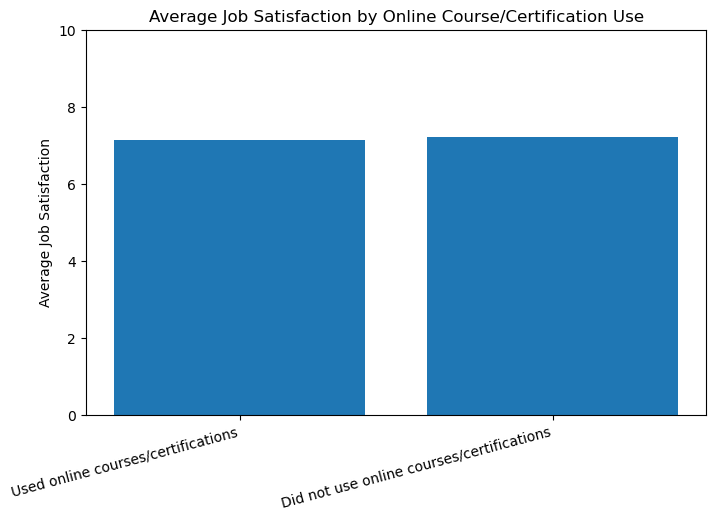

In [6]:
plt.figure(figsize=(8, 5))
plt.bar(group_summary["group"], group_summary["mean"])
plt.ylabel("Average Job Satisfaction")
plt.title("Average Job Satisfaction by Online Course/Certification Use")
plt.ylim(0, 10)
plt.xticks(rotation=15, ha="right")
plt.show()

## Assumption Checks

With a large survey dataset, normality tests can reject normality for very small deviations. These checks are useful context, but the practical size of the difference matters too.

In [7]:
rng = np.random.default_rng(42)

online_sample = (
    rng.choice(online_courses, 5000, replace=False)
    if len(online_courses) > 5000
    else online_courses
)

not_online_sample = (
    rng.choice(not_online_courses, 5000, replace=False)
    if len(not_online_courses) > 5000
    else not_online_courses
)

shapiro_online = stats.shapiro(online_sample)
shapiro_not_online = stats.shapiro(not_online_sample)
levene_result = stats.levene(online_courses, not_online_courses)

print(f"Shapiro-Wilk, online courses group: W={shapiro_online.statistic:.4f}, p={shapiro_online.pvalue:.4g}")
print(f"Shapiro-Wilk, no online courses group: W={shapiro_not_online.statistic:.4f}, p={shapiro_not_online.pvalue:.4g}")
print(f"Levene's test for equal variances: W={levene_result.statistic:.4f}, p={levene_result.pvalue:.4g}")

Shapiro-Wilk, online courses group: W=0.9133, p=7.727e-47
Shapiro-Wilk, no online courses group: W=0.9071, p=5.659e-48
Levene's test for equal variances: W=5.3388, p=0.02086


## Welch's t-test

In [8]:
alpha = 0.05

t_stat, t_p = stats.ttest_ind(
    online_courses,
    not_online_courses,
    equal_var=False
)

print(f"Welch's t-statistic: {t_stat:.4f}")
print(f"p-value: {t_p:.6f}")

if t_p < alpha:
    print(f"Result: Reject H0 at alpha={alpha}.")
else:
    print(f"Result: Fail to reject H0 at alpha={alpha}.")

Welch's t-statistic: -3.1584
p-value: 0.001591
Result: Reject H0 at alpha=0.05.


## Effect Size

In [9]:
def cohens_d(a, b):
    n1 = len(a)
    n2 = len(b)
    pooled_std = np.sqrt(
        ((n1 - 1) * a.var(ddof=1) + (n2 - 1) * b.var(ddof=1))
        / (n1 + n2 - 2)
    )
    return (a.mean() - b.mean()) / pooled_std

d = cohens_d(online_courses, not_online_courses)
print(f"Cohen's d: {d:.4f}")

Cohen's d: -0.0465


## Mann-Whitney U Robustness Check

In [10]:
u_stat, u_p = stats.mannwhitneyu(
    online_courses,
    not_online_courses,
    alternative="two-sided"
)

print(f"Mann-Whitney U statistic: {u_stat:.1f}")
print(f"p-value: {u_p:.6f}")

Mann-Whitney U statistic: 61671396.0
p-value: 0.001238


## Plain-English Interpretation

The Welch’s t-test found a statistically significant difference in average job satisfaction between respondents who used online courses/certifications and those who did not, t = -3.16, p = 0.0016.

Respondents who used online courses/certifications reported slightly lower average job satisfaction than respondents who did not. The average score was 7.13 for the online courses/certifications group and 7.22 for the comparison group.

However, the difference was very small. Cohen’s d was -0.047, which suggests the difference is not practically meaningful even though it is statistically significant.

The Mann-Whitney U test also found a statistically significant difference, p = 0.0012, which supports the direction of the Welch’s t-test result. However, this does not prove that online courses or certifications cause lower job satisfaction. The survey is observational, and respondents may have used multiple learning pathways. This result only shows that the two groups differed slightly in this sample.